In [1]:
# Imports dan paths

import pandas as pd, numpy as np, optuna, mlflow, xgboost as xgb
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
# Load data
DAILY_PARQUET = Path("../data/processed/daily_features.parquet")
df_daily = pd.read_parquet(DAILY_PARQUET)
df_daily.head()

,station_id,date_local,temp_13LT_C,rh_avg_pc,wind_avg_kmh,qff_avg_hPa,rain_mm,evap_mm,ffmc
0,96595,2015-01-01 00:00:00+00:00,32.2,71.39375,0.92600,1009.58750,3.0,4.0,73.688695
1,96595,2015-01-02 00:00:00+00:00,30.0,79.08750,0.92600,1010.58125,0.0,3.0,83.174782
2,96595,2015-01-03 00:00:00+00:00,31.1,79.30000,0.00000,1010.85625,0.0,3.0,84.831423
3,96595,2015-01-04 00:00:00+00:00,30.9,76.87500,1.15750,1009.85000,20.5,6.0,60.330249
4,96595,2015-01-05 00:00:00+00:00,29.2,85.48750,0.57875,1010.38750,10.8,6.0,58.220215


In [3]:
df_daily.tail()

,station_id,date_local,temp_13LT_C,rh_avg_pc,wind_avg_kmh,qff_avg_hPa,rain_mm,evap_mm,ffmc
16378,96655,2023-12-29 00:00:00+00:00,33.3,80.583333,6.019000,1009.350000,8.5,5.1,72.551152
16379,96655,2023-12-30 00:00:00+00:00,33.7,82.791667,6.173333,1008.712500,2.2,3.7,79.363064
16380,96655,2023-12-31 00:00:00+00:00,32.0,86.916667,6.250500,1009.204167,0.6,3.2,82.045694
16381,96655,2024-01-01 00:00:00+00:00,31.6,82.500000,6.250500,1009.150000,0.0,4.0,84.231300
16382,96655,2024-01-02 00:00:00+00:00,30.7,94.125000,5.787500,1008.450000,0.0,4.0,81.911864


In [4]:
df_daily["date_local"] = pd.to_datetime(df_daily["date_local"])

In [5]:
### Feature engineering – lags, rolling means, DOY encodings
LAGS  = [1, 3]
ROLLS = [3, 7]

df = df_daily.sort_values(["station_id", "date_local"]).set_index("date_local")

for col in ["temp_13LT_C", "rh_avg_pc", "wind_avg_kmh",
            "qff_avg_hPa", "rain_mm", "evap_mm"]:
    for k in LAGS:
        df[f"{col}_lag{k}"] = df.groupby("station_id")[col].shift(k)
    for w in ROLLS:
        df[f"{col}_roll{w}"] = (
            df.groupby("station_id")[col]
              .rolling(w, min_periods=1).mean()
              .droplevel(0)
        )

df["doy_sin"] = np.sin(2*np.pi*df.index.dayofyear / 365.25)
df["doy_cos"] = np.cos(2*np.pi*df.index.dayofyear / 365.25)
df["month"]   = df.index.month

# drop first-lag rows that now contain NaN
df = df.dropna(subset=[c for c in df.columns if "lag" in c]).reset_index()
df.head()


,date_local,station_id,temp_13LT_C,rh_avg_pc,wind_avg_kmh,qff_avg_hPa,rain_mm,evap_mm,ffmc,temp_13LT_C_lag1,...,rain_mm_lag3,rain_mm_roll3,rain_mm_roll7,evap_mm_lag1,evap_mm_lag3,evap_mm_roll3,evap_mm_roll7,doy_sin,doy_cos,month
0,2015-01-04 00:00:00+00:00,96595,30.9,76.87500,1.15750,1009.85000,20.5,6.0,60.330249,31.1,...,3.0,6.833333,5.875000,3.0,4.0,4.000000,4.000000,0.068755,0.997634,1
1,2015-01-05 00:00:00+00:00,96595,29.2,85.48750,0.57875,1010.38750,10.8,6.0,58.220215,30.9,...,0.0,10.433333,6.860000,6.0,3.0,5.000000,4.400000,0.085906,0.996303,1
2,2015-01-06 00:00:00+00:00,96595,30.0,82.90625,1.50475,1009.46250,32.5,6.0,60.075054,29.2,...,0.0,21.266667,11.133333,6.0,3.0,6.000000,4.666667,0.103031,0.994678,1
3,2015-01-07 00:00:00+00:00,96595,27.2,88.31875,2.08350,1010.45625,19.7,4.0,56.740650,30.0,...,20.5,21.000000,12.357143,6.0,6.0,5.333333,4.571429,0.120126,0.992759,1
4,2015-01-08 00:00:00+00:00,96595,28.6,84.60625,1.15750,1010.61250,6.3,4.0,62.820614,27.2,...,10.8,19.500000,12.828571,4.0,6.0,4.666667,4.571429,0.137185,0.990545,1


In [7]:
df.to_csv("/home/rzby/ffmc_dc/data/processed/feature_engineering.csv", index=False)

In [8]:
###  NEW – station-stratified random split

from sklearn.utils import shuffle

test_frac = 0.20
test_idx  = (
    df.groupby('station_id', group_keys=False)
      .apply(lambda g: g.sample(frac=test_frac, random_state=42))
      .index
)

train_idx = df.index.difference(test_idx)

train = df.loc[train_idx].copy()
test  = df.loc[test_idx].copy()

PRED_COLS = [c for c in df.columns if c not in ('station_id', 'ffmc', 'date_local')]
X_train, y_train = train[PRED_COLS], train['ffmc']
X_test,  y_test  = test[PRED_COLS],  test['ffmc']
print(f"Train rows: {len(train):,}  |  Test rows: {len(test):,}")

print(y_train[:10])
print(y_test[:10])


Train rows: 13,095  |  Test rows: 3,273
1     58.220215
2     60.075054
3     56.740650
4     62.820614
5     81.446023
6     65.017678
7     60.586865
8     53.526273
9     60.842692
10    50.632887
Name: ffmc, dtype: float64
2210    75.815924
2338    84.784616
1656    83.212600
1652    79.109409
1451    59.156528
2638    67.484119
864     80.991939
238     86.612615
2576    56.095540
1366    83.784558
Name: ffmc, dtype: float64


/tmp/ipykernel_4317/816413710.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(frac=test_frac, random_state=42))


In [9]:
### Optuna + MLflow tuning – find best XGBoost hyper-params
mlflow.set_tracking_uri("file:./mlruns")
mlflow.set_experiment("ffmc_xgb")

def objective(trial):
    params = {
        "n_estimators"     : trial.suggest_int("n_estimators", 300, 1200),
        "max_depth"        : trial.suggest_int("max_depth", 3, 10),
        "learning_rate"    : trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample"        : trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree" : trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "random_state"     : 42,
        "n_jobs"           : -1,
    }
    model = xgb.XGBRegressor(**params)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, pred))

    with mlflow.start_run():
        mlflow.log_params(params)
        mlflow.log_metric("rmse", rmse)
        mlflow.xgboost.log_model(model, "model")
    return rmse

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=40, show_progress_bar=True)

best_rmse = study.best_value
print("Best RMSE:", best_rmse)


2025/08/02 19:16:03 INFO mlflow.tracking.fluent: Experiment with name 'ffmc_xgb' does not exist. Creating a new experiment.
[I 2025-08-02 19:16:03,935] A new study created in memory with name: no-name-9601044a-0ae4-4a26-b9cd-62271c7318f7


  0%|          | 0/40 [00:00<?, ?it/s]

2025/08/02 19:16:05 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
/home/rzby/miniforge3/envs/atmo-ann/lib/python3.11/site-packages/xgboost/sklearn.py:1028: UserWarning: [19:16:05] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1748293041487/work/src/c_api/c_api.cc:1427: Saving model in the UBJSON format as default.  You can use file extension: `json`, `ubj` or `deprecated` to choose between formats.
  self.get_booster().save_model(fname)
2025/08/02 19:16:08 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


[I 2025-08-02 19:16:08,745] Trial 0 finished with value: 0.46339120994573463 and parameters: {'n_estimators': 904, 'max_depth': 3, 'learning_rate': 0.12999591820254017, 'subsample': 0.624515942531275, 'colsample_bytree': 0.8117668781418305}. Best is trial 0 with value: 0.46339120994573463.


2025/08/02 19:16:34 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
/home/rzby/miniforge3/envs/atmo-ann/lib/python3.11/site-packages/xgboost/sklearn.py:1028: UserWarning: [19:16:34] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1748293041487/work/src/c_api/c_api.cc:1427: Saving model in the UBJSON format as default.  You can use file extension: `json`, `ubj` or `deprecated` to choose between formats.
  self.get_booster().save_model(fname)
2025/08/02 19:16:36 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


...

[I 2025-08-02 19:21:34,922] Trial 37 finished with value: 0.38671240763960324 and parameters: {'n_estimators': 1006, 'max_depth': 5, 'learning_rate': 0.020064964474002606, 'subsample': 0.9003283479538485, 'colsample_bytree': 0.9661529283310546}. Best is trial 9 with value: 0.38636413749109183.


2025/08/02 19:21:37 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
/home/rzby/miniforge3/envs/atmo-ann/lib/python3.11/site-packages/xgboost/sklearn.py:1028: UserWarning: [19:21:37] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1748293041487/work/src/c_api/c_api.cc:1427: Saving model in the UBJSON format as default.  You can use file extension: `json`, `ubj` or `deprecated` to choose between formats.
  self.get_booster().save_model(fname)
2025/08/02 19:21:39 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


[I 2025-08-02 19:21:39,290] Trial 38 finished with value: 0.45243653975433606 and parameters: {'n_estimators': 1001, 'max_depth': 4, 'learning_rate': 0.028682221905154667, 'subsample': 0.8766613004997058, 'colsample_bytree': 0.693594926090923}. Best is trial 9 with value: 0.38636413749109183.


2025/08/02 19:21:42 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
/home/rzby/miniforge3/envs/atmo-ann/lib/python3.11/site-packages/xgboost/sklearn.py:1028: UserWarning: [19:21:42] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1748293041487/work/src/c_api/c_api.cc:1427: Saving model in the UBJSON format as default.  You can use file extension: `json`, `ubj` or `deprecated` to choose between formats.
  self.get_booster().save_model(fname)
2025/08/02 19:21:44 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


[I 2025-08-02 19:21:44,587] Trial 39 finished with value: 0.3866745272554823 and parameters: {'n_estimators': 944, 'max_depth': 5, 'learning_rate': 0.02613061690808117, 'subsample': 0.9785011252625153, 'colsample_bytree': 0.9689551711366851}. Best is trial 9 with value: 0.38636413749109183.
Best RMSE: 0.38636413749109183


In [11]:
### Retrieve best model & evaluate RQ 1 metrics
best_run = mlflow.search_runs(order_by=["metrics.rmse"], max_results=1).iloc[0]
model_uri = f"runs:/{best_run.run_id}/model"
best_model = mlflow.xgboost.load_model(model_uri)

test["pred_xgb"] = best_model.predict(X_test)

overall = {
    "RMSE": np.sqrt(mean_squared_error(y_test, test["pred_xgb"])),
    "MAE" : mean_absolute_error(y_test, test["pred_xgb"]),
    "R2"  : r2_score(y_test, test["pred_xgb"]),
}
print("=== Overall test metrics ===")
for k, v in overall.items():
    print(f"{k:4s}: {v:6.3f}")

per_station = (
    test.groupby("station_id")
        .apply(lambda g: pd.Series({
            "RMSE": np.sqrt(mean_squared_error(g["ffmc"], g["pred_xgb"])),
            "MAE" : mean_absolute_error(g["ffmc"], g["pred_xgb"]),
            "R2"  : r2_score(g["ffmc"], g["pred_xgb"]),
        }))
        .sort_index()
)
per_station


=== Overall test metrics ===
RMSE:  0.386
MAE :  0.265
R2  :  0.998


/tmp/ipykernel_4317/3211267093.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


,RMSE,MAE,R2
station_id,,,
96595,0.514594,0.333444,0.997537
96645,0.367408,0.267773,0.998272
96651,0.340175,0.242268,0.998300
96653,0.348939,0.242493,0.998206
96655,0.329776,0.240995,0.998125


In [12]:
per_station.to_csv("/home/rzby/ffmc_dc/reports/xgb_per_station.csv")

In [13]:
### ⬛ ANN – build, train, predict  (CELL 5-A)

from tensorflow import keras
from sklearn.preprocessing import StandardScaler

# 1. scale predictors
scaler_ann = StandardScaler().fit(X_train)
Xtr_ann = scaler_ann.transform(X_train)
Xte_ann = scaler_ann.transform(X_test)

# 2. build model
ann = keras.Sequential([
    keras.layers.Dense(128, activation="relu", input_shape=(Xtr_ann.shape[1],)),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(1)         # linear output
])
ann.compile(loss="mse", optimizer=keras.optimizers.Adam(1e-3), metrics=["mae"])

# 3. train with early stopping
callback = keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True)
history = ann.fit(Xtr_ann, y_train,
                  validation_split=0.2,
                  epochs=300,
                  batch_size=128,
                  verbose=0,
                  callbacks=[callback])

# 4. predict
test["pred_ann"] = ann.predict(Xte_ann, verbose=0).ravel()


2025-08-02 19:43:09.289844: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/rzby/miniforge3/envs/atmo-ann/lib/python3.11/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
### ⬛ SVM (RBF) – scale, tune C & γ quickly, predict  (CELL 5-B)

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV

pipe = make_pipeline(StandardScaler(), SVR(kernel="rbf"))

param_grid = {
    "svr__C":      [1, 10, 100],
    "svr__gamma":  ["scale", 0.01, 0.1],
    "svr__epsilon":[0.1, 0.2],
}
grid = GridSearchCV(pipe, param_grid, cv=3, scoring="neg_root_mean_squared_error", n_jobs=-1)
grid.fit(X_train, y_train)

print("Best SVM params:", grid.best_params_)
test["pred_svm"] = grid.best_estimator_.predict(X_test)


Best SVM params: {'svr__C': 100, 'svr__epsilon': 0.2, 'svr__gamma': 0.01}


In [15]:
### ▶▶ Collect overall & per-station metrics for all three models  (CELL 6 updated)

def metric_dict(y_true, y_hat):
    return {
        "RMSE": np.sqrt(mean_squared_error(y_true, y_hat)),
        "MAE" : mean_absolute_error(y_true, y_hat),
        "R2"  : r2_score(y_true, y_hat),
    }

overall = pd.DataFrame({
    "XGB" : metric_dict(y_test, test["pred_xgb"]),
    "ANN" : metric_dict(y_test, test["pred_ann"]),
    "SVM" : metric_dict(y_test, test["pred_svm"]),
}).T
print("=== Overall test-set metrics ===")
overall


=== Overall test-set metrics ===


,RMSE,MAE,R2
XGB,0.386364,0.265424,0.998078
ANN,0.584939,0.429120,0.995595
SVM,2.701973,1.895916,0.906013


In [16]:
overall.to_csv("/home/rzby/ffmc_dc/reports/overall_results.csv")

In [ ]:
test[["ffmc", "pred", "pred_ann", "pred_svm"]].to_csv(Path("../reports/output_table.csv"), index=False)

In [17]:
### Per-station RMSE for each model  (CELL 6-bis)

per_station_all = (
    test.groupby("station_id")
        .apply(lambda g: pd.Series({
            "XGB_RMSE": np.sqrt(mean_squared_error(g["ffmc"], g["pred_xgb"])),
            "ANN_RMSE": np.sqrt(mean_squared_error(g["ffmc"], g["pred_ann"])),
            "SVM_RMSE": np.sqrt(mean_squared_error(g["ffmc"], g["pred_svm"])),
        }))
)
per_station_all


/tmp/ipykernel_4317/2792447399.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


,XGB_RMSE,ANN_RMSE,SVM_RMSE
station_id,,,
96595,0.514594,0.805969,3.309160
96645,0.367408,0.583639,2.535808
96651,0.340175,0.469961,2.432343
96653,0.348939,0.482028,2.756636
96655,0.329776,0.516217,2.366454


In [18]:
per_station_all.to_csv("/home/rzby/ffmc_dc/reports/rmse_per_station.csv")

In [19]:
# per station MAE
per_station_mae = (
    test.groupby("station_id")
        .apply(lambda g: pd.Series({
            "XGB_MAE": mean_absolute_error(g["ffmc"], g["pred_xgb"]),
            "ANN_MAE": mean_absolute_error(g["ffmc"], g["pred_ann"]),
            "SVM_MAE": mean_absolute_error(g["ffmc"], g["pred_svm"]),
        }))
)
per_station_mae

/tmp/ipykernel_4317/2935027685.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


,XGB_MAE,ANN_MAE,SVM_MAE
station_id,,,
96595,0.333444,0.583503,2.342621
96645,0.267773,0.421240,1.841946
96651,0.242268,0.362080,1.762107
96653,0.242493,0.374153,1.879910
96655,0.240995,0.404122,1.652300


In [20]:
per_station_mae.to_csv("/home/rzby/ffmc_dc/reports/mae_per_station.csv")

In [21]:
# per station R2
per_station_r2 = (
    test.groupby("station_id")
        .apply(lambda g: pd.Series({
            "XGB_R2": r2_score(g["ffmc"], g["pred_xgb"]),
            "ANN_R2": r2_score(g["ffmc"], g["pred_ann"]),
            "SVM_R2": r2_score(g["ffmc"], g["pred_svm"]),
        }))
)
per_station_r2

/tmp/ipykernel_4317/314350480.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


,XGB_R2,ANN_R2,SVM_R2
station_id,,,
96595,0.997537,0.993958,0.898142
96645,0.998272,0.995638,0.917662
96651,0.998300,0.996756,0.913102
96653,0.998206,0.996577,0.888038
96655,0.998125,0.995405,0.903441


In [22]:
per_station_r2.to_csv("/home/rzby/ffmc_dc/reports/r2_per_station.csv")

In [ ]:
### Visual 3 – overall RMSE comparison  (CELL 7-bis)

overall.RMSE.plot.bar(rot=0, figsize=(4,3))
plt.ylabel("RMSE"); plt.title("Model comparison – overall RMSE")
plt.tight_layout(); plt.savefig(Path("../reports/figures/rmse_comparison.png"))
plt.show()

In [ ]:
### Visual 4 – per-station RMSE heatmap  (CELL 8-bis)
import seaborn as sns

plt.figure(figsize=(6,5))
sns.heatmap(per_station_all.filter(like="_RMSE").T,
            annot=True, fmt=".2f", cmap="YlOrRd")
plt.title("RMSE by station & model"); plt.xlabel("WMO station"); plt.ylabel("")
plt.tight_layout()
plt.savefig(Path("../reports/figures/rmse_station_comparison.png"))
plt.show()


In [ ]:
### Visual 1 – prediction vs observation scatter (CELL 7)
plt.figure(figsize=(5,5))
plt.scatter(test["ffmc"], test["pred"], s=10, alpha=0.5)
plt.plot([60,100], [60,100], "k--")
plt.xlabel("Observed FFMC"); plt.ylabel("Predicted FFMC")
plt.title("Overall test set – XGBoost")
plt.grid(True); plt.tight_layout()
plt.savefig(Path("../reports/figures/scatter_xgboost.png"))
plt.show()


In [ ]:
### RQ 2 – SHAP feature importance  (CELL 9)
import shap
sample = df.sample(6000, random_state=0)   # speed; adjust if GPU available
X_sample = sample[PRED_COLS]

explainer = shap.Explainer(best_model)
shap_values = explainer(X_sample, check_additivity=False)

shap.summary_plot(shap_values, X_sample, show=False)
plt.title("SHAP summary – key FFMC drivers")
plt.tight_layout()
plt.savefig(Path("../reports/figures/feature_xgboost.png"))
plt.show()


In [25]:
# DUMP BEST MODEL
import json, joblib, numpy as np, pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

MODELS_DIR = Path("/home/rzby/ffmc_dc/models")
print(MODELS_DIR)
REPORTS_DIR = Path("/home/rzby/ffmc_dc/reports")
FIG_DIR = REPORTS_DIR / "figures"
OUT_DIR = Path("/home/rzby/ffmc_dc/reports")

PRED_COLS = [c for c in df.columns if c not in ("station_id","ffmc","date_local")]

meta = {
    "best_model": "XGB",
    "pred_cols": PRED_COLS
}

joblib.dump(best_model, MODELS_DIR / "best_model_xgb.pkl")
meta["path"] = str(MODELS_DIR / "best_model_xgb.pkl")
meta["kind"] = "xgboost"

with open(MODELS_DIR / "best_model_meta.json", "w") as f:
    json.dump(meta, f, indent=2)

print("Saved:", meta)

/home/rzby/ffmc_dc/models
Saved: {'best_model': 'XGB', 'pred_cols': ['temp_13LT_C', 'rh_avg_pc', 'wind_avg_kmh', 'qff_avg_hPa', 'rain_mm', 'evap_mm', 'temp_13LT_C_lag1', 'temp_13LT_C_lag3', 'temp_13LT_C_roll3', 'temp_13LT_C_roll7', 'rh_avg_pc_lag1', 'rh_avg_pc_lag3', 'rh_avg_pc_roll3', 'rh_avg_pc_roll7', 'wind_avg_kmh_lag1', 'wind_avg_kmh_lag3', 'wind_avg_kmh_roll3', 'wind_avg_kmh_roll7', 'qff_avg_hPa_lag1', 'qff_avg_hPa_lag3', 'qff_avg_hPa_roll3', 'qff_avg_hPa_roll7', 'rain_mm_lag1', 'rain_mm_lag3', 'rain_mm_roll3', 'rain_mm_roll7', 'evap_mm_lag1', 'evap_mm_lag3', 'evap_mm_roll3', 'evap_mm_roll7', 'doy_sin', 'doy_cos', 'month'], 'path': '/home/rzby/ffmc_dc/models/best_model_xgb.pkl', 'kind': 'xgboost'}


In [29]:
# Predict Last 3 Days and Prepare for Mapping

# Load features with coordinates
features = pd.read_csv("/home/rzby/ffmc_dc/data/processed/feature_engineering.csv")
features['station_id'] = features['station_id'].astype(str)
features['date_local'] = pd.to_datetime(features['date_local'])

# Ensure lon/lat are present; if not, read from `data/stations.csv`
if not {"lon","lat"}.issubset(features.columns):
    stations_csv = Path("/home/rzby/ffmc_dc/data/stations.csv")
    if not stations_csv.exists():
        raise FileNotFoundError(
            "No lon/lat in features and stations.csv not found.\n"
            "Create data/stations.csv with columns: station_id,lon,lat[,name]"
        )
    stations = pd.read_csv(stations_csv)
    stations['station_id'] = stations['station_id'].astype(str)
    features = features.merge(stations, on="station_id", how="left")

# pick last 3 *available* dates
last_date = features["date_local"].max()
target_dates = pd.date_range(last_date - pd.Timedelta(days=2), last_date, freq="D")
print("Target dates:", target_dates.date.tolist())

# load best artefacts back (to make this cell standalone)
with open(MODELS_DIR / "best_model_meta.json") as f:
    meta = json.load(f)

kind = meta["kind"]
pred_cols = meta["pred_cols"]

if kind == "xgboost":
    model = joblib.load(meta["path"])
elif kind == "ann":
    from tensorflow import keras
    model = keras.models.load_model(meta["path"])
    scaler_ann = joblib.load(meta["scaler"])
elif kind == "svm":
    model = joblib.load(meta["path"])

pred_rows = []
for d in target_dates:
    sub = features.loc[features["date_local"] == d].copy()
    if sub.empty:
        continue
    Xd = sub[pred_cols].copy()
    if kind == "ann":
        Xd = scaler_ann.transform(Xd)
        yhat = model.predict(Xd, verbose=0).ravel()
    else:
        yhat = model.predict(Xd)
    sub["ffmc_pred"] = yhat
    pred_rows.append(sub[["station_id","date_local","lon","lat","ffmc","ffmc_pred"]])

pred3 = pd.concat(pred_rows, ignore_index=True)
pred3.to_csv(OUT_DIR / "pred_last3days_points.csv", index=False)
pred3.head()


Target dates: [datetime.date(2023, 12, 31), datetime.date(2024, 1, 1), datetime.date(2024, 1, 2)]


,station_id,date_local,lon,lat,ffmc,ffmc_pred
0,96595,2023-12-31 00:00:00+00:00,114.53,-0.56,74.916475,74.949554
1,96645,2023-12-31 00:00:00+00:00,111.66,-2.73,60.212280,60.225731
2,96651,2023-12-31 00:00:00+00:00,112.93,-2.55,62.173506,62.400558
3,96653,2023-12-31 00:00:00+00:00,114.90,-1.67,71.691622,71.587807
4,96655,2023-12-31 00:00:00+00:00,113.95,-2.22,82.045694,81.840324


In [30]:
pred3

,station_id,date_local,lon,lat,ffmc,ffmc_pred
0,96595,2023-12-31 00:00:00+00:00,114.53,-0.56,74.916475,74.949554
1,96645,2023-12-31 00:00:00+00:00,111.66,-2.73,60.212280,60.225731
2,96651,2023-12-31 00:00:00+00:00,112.93,-2.55,62.173506,62.400558
3,96653,2023-12-31 00:00:00+00:00,114.90,-1.67,71.691622,71.587807
4,96655,2023-12-31 00:00:00+00:00,113.95,-2.22,82.045694,81.840324
5,96595,2024-01-01 00:00:00+00:00,114.53,-0.56,82.565687,82.784431
6,96645,2024-01-01 00:00:00+00:00,111.66,-2.73,79.710869,79.820694
7,96651,2024-01-01 00:00:00+00:00,112.93,-2.55,79.562783,79.693794
8,96653,2024-01-01 00:00:00+00:00,114.90,-1.67,83.914953,83.922455
9,96655,2024-01-01 00:00:00+00:00,113.95,-2.22,84.231300,83.847755


In [31]:
pred3.to_csv(f'{REPORTS_DIR}/mapping_output.csv', index=False)

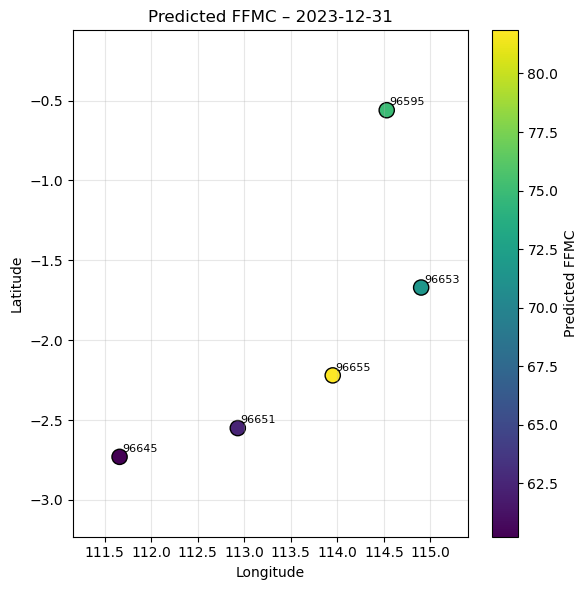

Saved: /home/rzby/ffmc_dc/reports/figures/ffmc_pred_points_2023-12-31.png


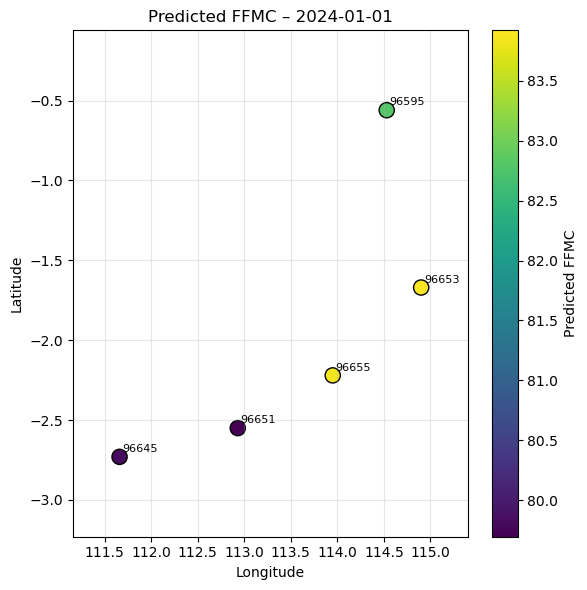

Saved: /home/rzby/ffmc_dc/reports/figures/ffmc_pred_points_2024-01-01.png


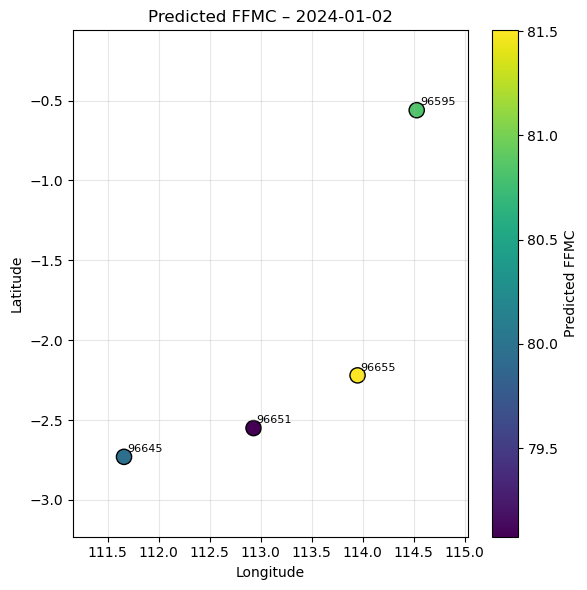

Saved: /home/rzby/ffmc_dc/reports/figures/ffmc_pred_points_2024-01-02.png


In [32]:
# MAKE POINTS MAP
import matplotlib.pyplot as plt

# Optional: province boundary
PROV_SHP = None  # e.g., "data/geo/kalimantan_tengah.shp"

def plot_points(df_day, date_label, out_png):
    plt.figure(figsize=(6,6))
    if PROV_SHP:
        import geopandas as gpd
        prov = gpd.read_file(PROV_SHP).to_crs(4326)
        prov.plot(edgecolor="black", facecolor="none")
    sc = plt.scatter(df_day["lon"], df_day["lat"],
                     c=df_day["ffmc_pred"], s=120, edgecolor="k")
    plt.colorbar(sc, label="Predicted FFMC")
    for _, r in df_day.iterrows():
        plt.text(r["lon"]+0.03, r["lat"]+0.03, str(r["station_id"]), fontsize=8)
    plt.title(f"Predicted FFMC – {date_label}")
    plt.xlabel("Longitude"); plt.ylabel("Latitude")
    # set a reasonable frame around the points
    xmin, xmax = df_day["lon"].min()-0.5, df_day["lon"].max()+0.5
    ymin, ymax = df_day["lat"].min()-0.5, df_day["lat"].max()+0.5
    plt.xlim(xmin, xmax); plt.ylim(ymin, ymax)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(out_png, dpi=300)
    plt.show()

for d, g in pred3.groupby("date_local"):
    out_png = FIG_DIR / f"ffmc_pred_points_{pd.to_datetime(d).date()}.png"
    plot_points(g, pd.to_datetime(d).date(), out_png)
    print("Saved:", out_png)
